# Relatório Final - Data Science
## Bachelor's Degree in Computer Science / PUCPR (2026-1)

**Prof. Rayson Laroca**

`Alander Menezes Arantes de Ávila` - `menezes.alander@pucpr.edu.br`

`Giancarlo Nunes Perli` - `giancarlo.perli@sanrocco.com.br`

`Gustavo Faria Cardoso` - `faria.cardoso@pucpr.edu.br`

`Paulo Henrique Perin` - `paulo.perin@pucpr.edu.br`

`Pedro Lucas Ghezzi Bittencourt` - `pedro.bittencourt@pucpr.edu.br`

# Import the libs you need

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew as _skew, kurtosis as _kurt

# Load your data

#### https://www.kaggle.com/datasets/sakhawat18/asteroid-dataset/data

In [ ]:
df = pd.read_csv("https://github.com/aland3r/asteroids/releases/download/dataset/asteroids.csv")

/tmp/ipykernel_3954/397749549.py:1: DtypeWarning: Columns (3,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("https://github.com/aland3r/asteroids/releases/download/dataset/asteroids.csv")


In [ ]:
df.shape

(958524, 45)

In [ ]:
df.columns

Index(['id', 'spkid', 'full_name', 'pdes', 'name', 'prefix', 'neo', 'pha', 'H',
       'diameter', 'albedo', 'diameter_sigma', 'orbit_id', 'epoch',
       'epoch_mjd', 'epoch_cal', 'equinox', 'e', 'a', 'q', 'i', 'om', 'w',
       'ma', 'ad', 'n', 'tp', 'tp_cal', 'per', 'per_y', 'moid', 'moid_ld',
       'sigma_e', 'sigma_a', 'sigma_q', 'sigma_i', 'sigma_om', 'sigma_w',
       'sigma_ma', 'sigma_ad', 'sigma_n', 'sigma_tp', 'sigma_per', 'class',
       'rms'],
      dtype='object')

### The complete dataset we selected contains 958,524 asteroid records and 45 columns. We do not use every parameter. We only want to investigate which orbital and physical features characterize potentially hazardous asteroids (`pha = Y`), compared to non-hazardous ones (`pha = N`).

### We remove identifier columns (id, spkid, full_name, pdes, name, prefix, orbit_id): they identify catalog entries but do not describe physical or orbital properties for modelling. We also discard rows without a pha value (`pha = NaN`), since the label is required for supervised analysis.

In [ ]:
# Rows with missing pha aren't relevant to us
df_clean = df.dropna(subset=['pha'])

# Columns with id parameters aren't needed
# we're not analysing individual cases
id_cols = ['id', 'spkid', 'full_name', 'pdes', 'name', 'prefix', 'orbit_id']
df_clean = df_clean.drop(columns=id_cols, errors='ignore')

In [ ]:
df_clean.shape

(938603, 38)

In [ ]:
df_clean.columns

Index(['neo', 'pha', 'H', 'diameter', 'albedo', 'diameter_sigma', 'epoch',
       'epoch_mjd', 'epoch_cal', 'equinox', 'e', 'a', 'q', 'i', 'om', 'w',
       'ma', 'ad', 'n', 'tp', 'tp_cal', 'per', 'per_y', 'moid', 'moid_ld',
       'sigma_e', 'sigma_a', 'sigma_q', 'sigma_i', 'sigma_om', 'sigma_w',
       'sigma_ma', 'sigma_ad', 'sigma_n', 'sigma_tp', 'sigma_per', 'class',
       'rms'],
      dtype='object')

In [ ]:
df_clean['pha'].value_counts()

,count
pha,
N,936537
Y,2066


In [ ]:
df_clean["pha"].value_counts(normalize=True)

,proportion
pha,
N,0.997799
Y,0.002201


# Statistical Description

Below we report the key characteristics of the dataset: number of instances, features, classes, class distribution, missing values, data types, and a correlation preview.

#### Key characteristics of the dataset after cleaning:
* 938,603 instances;
* 38 features;
* 2 classes (`pha`= Yes/No);
* 99.78% harmless (`pha`= No) and 0.22% hazardous (`pha` = Yes)

In [ ]:
print("=== Missing Values (top 15 columns) ===")
missing = df_clean.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df_clean) * 100).round(2)
miss_df = pd.DataFrame({'missing': missing, 'pct': missing_pct})
print(miss_df[miss_df['missing'] > 0].to_string())

print("\n=== Data Types ===")
print(df_clean.dtypes.value_counts())

print(f"\nNumeric columns: {df_clean.select_dtypes(include='number').shape[1]}")
print(f"Categorical/object columns: {df_clean.select_dtypes(include='object').shape[1]}")

print("\n=== Descriptive Statistics (numeric columns) ===")
df_clean.describe().round(4)

In [ ]:
numeric_cols = df_clean.select_dtypes(include='number').columns
corr = df_clean[numeric_cols].corr(method='pearson')

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.3, fmt='.1f', annot=False)
plt.title('Pearson Correlation Matrix — All Numeric Features', fontsize=14)
plt.tight_layout()
plt.show()

#### Additional observations

* **Missing values:** Several columns have significant gaps — `diameter` (~86 % missing), `albedo` (~86 %), and their uncertainty columns. Columns like `name` and `prefix` were already dropped during cleaning. The orbital parameters (`e`, `a`, `q`, `i`, …) are nearly complete.
* **Data types:** 35 numeric columns and 3 object/categorical columns (`neo`, `pha`, `class`). Two time-related object columns (`epoch_cal`, `tp_cal`) store calendar dates as strings.
* **Correlation preview:** The heatmap above reveals strong linear relationships among orbital parameters — for example `a` (semi-major axis), `ad` (aphelion distance), `per` / `per_y` (orbital period) are highly correlated, which is expected from Kepler's third law. We will investigate these correlations more deeply in the multivariate section using Spearman's method.

# Univariate data analysis

Below we perform univariate analysis on **20 variables**, covering all key orbital, physical, and quality-of-fit parameters. For each variable we report: definition (in plain language), distribution type, skewness, kurtosis, mean, standard deviation, and contextual interpretation.

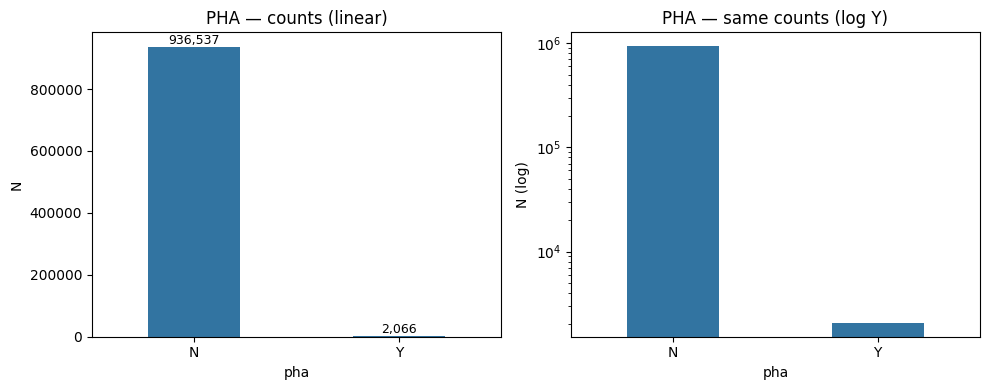

In [ ]:
# Univariate 1: Real proportions of PHA

vc = df_clean["pha"].value_counts().reindex(["N", "Y"])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.barplot(x=vc.index, y=vc.values, ax=axes[0], width=0.45)
axes[0].set_title("PHA — counts (linear)")
axes[0].set_xlabel("pha")
axes[0].set_ylabel("N")
for i, v in enumerate(vc.values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)

sns.barplot(x=vc.index, y=vc.values, ax=axes[1], width=0.45)
axes[1].set_yscale("log")
axes[1].set_title("PHA — same counts (log Y)")
axes[1].set_xlabel("pha")
axes[1].set_ylabel("N (log)")

plt.tight_layout()
plt.show()

#### Variable 1 — `pha`: Potentially Hazardous Asteroid

**Definition:** A binary label (`Y` / `N`) assigned by NASA. An asteroid is classified as **potentially hazardous** if it is large enough (H ≤ 22, roughly diameter ≥ 140 m) **and** its orbit comes close enough to Earth (MOID ≤ 0.05 AU). In plain terms: "could it hit us and would it matter?"

**Distribution:** Extremely imbalanced categorical — as reported in the Statistical Description above. This is the target variable for the entire analysis.

**Implication:** The severe class imbalance means any downstream classifier would achieve > 99 % accuracy by simply predicting “N”. Balanced sampling or specialized techniques will be essential.

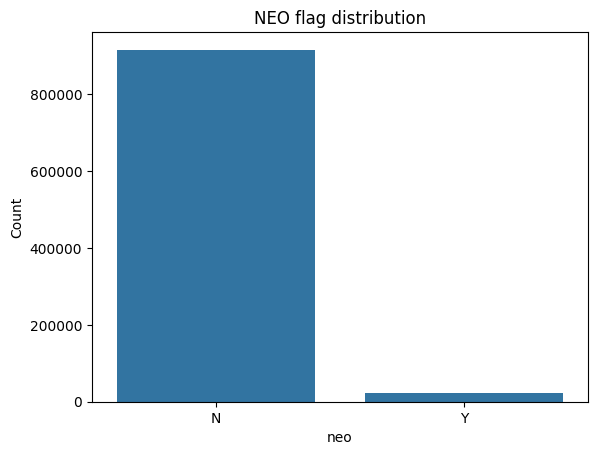

In [ ]:
# Univariate 2: Real proportions of near-Earth flag

sns.countplot(data=df_clean, x="neo", order=df_clean["neo"].value_counts().index)
plt.title("NEO flag distribution")
plt.xlabel("neo")
plt.ylabel("Count")
plt.show()

#### Variable 2 — `neo`: Near-Earth Object flag

**Definition:** A binary flag (`Y` / `N`). An asteroid is a **Near-Earth Object** if its perihelion distance (closest approach to the Sun) is less than 1.3 AU. Think of it as: "does this asteroid's orbit bring it into Earth's neighbourhood?" All PHAs are NEOs, but not all NEOs are PHAs (they might be too small).

**Distribution:** Imbalanced categorical — the vast majority of catalogued asteroids orbit in the main belt (between Mars and Jupiter) and are **not** near-Earth objects. NEO = Y is a necessary but not sufficient condition for PHA = Y.

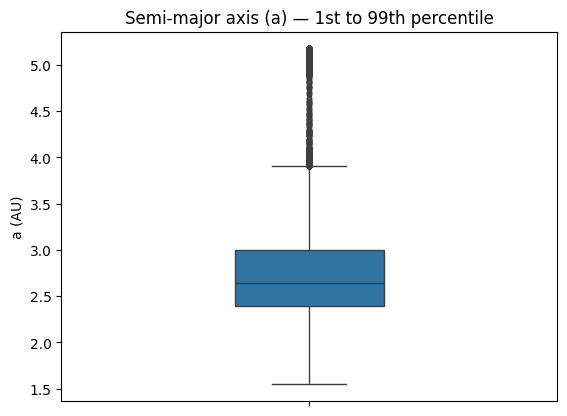

In [ ]:
# Univariate 3: # average distance from the Sun in AU; defines the orbit's overall size

data = df_clean["a"].dropna()
p01, p99 = data.quantile(0.01), data.quantile(0.99)
sns.boxplot(data=data[(data >= p01) & (data <= p99)], width=0.3, fliersize=3)
plt.title("Semi-major axis (a) — 1st to 99th percentile")
plt.ylabel("a (AU)")
plt.show()

# Most objects orbit at ~2.6 AU (main belt); right-skewed with upper outliers from wider-orbit populations.

#### Variable 3 — `a`: Semi-major Axis (AU)

**Definition:** The average distance from the asteroid to the Sun, measured in Astronomical Units (1 AU = Earth–Sun distance ≈ 150 million km). Think of it as the **"average orbit radius"**. A value of 2.5 AU means the asteroid orbits roughly 2.5 times farther from the Sun than Earth.

**Distribution:** **Right-skewed unimodal.** The dominant peak sits around 2.2–2.8 AU — the **main asteroid belt** between Mars and Jupiter. A long right tail extends toward distant orbits (Trojans, Centaurs).

**Skewness:** Positive — the bulk of asteroids are in the main belt, with increasingly rare objects at larger distances.

**Kurtosis:** Leptokurtic — a sharp main-belt peak with heavy tails.

**Mean and Std in context:** The mean a ≈ 2.7 AU corresponds to the heart of the main belt. The standard deviation captures the spread from near-Earth orbits (~1 AU) to distant populations (> 5 AU). PHAs, by definition, must have orbits that approach Earth, so they concentrate at **low** values of a.

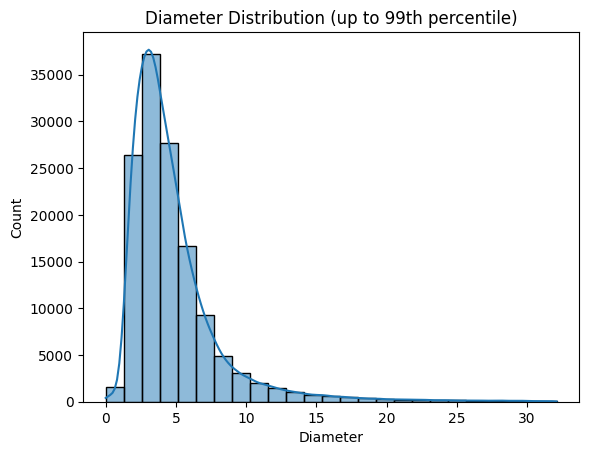

count    136209.000000
mean          5.506429
std           9.425164
min           0.002500
25%           2.780000
50%           3.972000
75%           5.765000
max         939.400000
Name: diameter, dtype: float64


In [ ]:
# Univariate 5: physical size of the asteroid in km; only ~14% of rows have a measured diameter

data = df_clean.loc[df_clean['diameter'] > 0, 'diameter']

p99 = data.quantile(0.99)

sns.histplot(data[data <= p99], bins=25, kde=True)
plt.title('Diameter Distribution (up to 99th percentile)')
plt.xlabel('Diameter')
plt.ylabel('Count')
plt.show()

print(data.describe())

In [ ]:
df_clean["diameter"].median()

3.972

#### Variable 4 — `diameter`: Physical Diameter (km)

**Definition:** The physical size of the asteroid in kilometres. Only ~14 % of the catalogue has a measured diameter — typically larger, brighter objects that are easier to observe. This introduces a **selection bias**: the distribution underrepresents small asteroids.

**Distribution:** **Strongly right-skewed.** Most measured asteroids are small (under ~50 km), with a few giants (e.g., Ceres at ~940 km) stretching the tail far to the right. The median is much lower than the mean, confirming the skew.

**Skewness:** Very high positive — the long right tail from rare giant asteroids.

**Kurtosis:** Leptokurtic — a sharp peak at small diameters with extreme outliers.

**Mean and Std in context:** The mean diameter is inflated by a handful of very large objects. The median (~15–20 km) is a more representative measure of a "typical" measured asteroid. Since PHAs must have H ≤ 22 (roughly ≥ 140 m), diameter is conceptually relevant but sparsely populated.


In [ ]:
# df_clean contém apenas pha em {'Y','N'}

# separar classes
df_y = df_clean[df_clean['pha'] == 'Y'].copy()
df_n = df_clean[df_clean['pha'] == 'N'].copy()

# amostra balanceada: mesma quantidade de N que de Y
n_bal = len(df_y)
df_n_bal = df_n.sample(n=n_bal, random_state=42)

# conjunto balanceado final
df_sample = pd.concat([df_y, df_n_bal], ignore_index=True)
df_sample = df_sample.sample(frac=1, random_state=42).reset_index(drop=True)

# verificação
print("df_sample shape:", df_sample.shape)
print(df_sample['pha'].value_counts())
print(df_sample['pha'].value_counts(normalize=True))


df_sample shape: (4132, 38)
pha
Y    2066
N    2066
Name: count, dtype: int64
pha
Y    0.5
N    0.5
Name: proportion, dtype: float64


#### Balanced Sampling

The class imbalance in `pha` makes it hard to compare the two groups visually. We build a **balanced sample** (equal numbers of Y and N) with a fixed random seed for exploratory plots. Population-level statistics still come from the full `df_clean`; the balanced sample is used only for fair visual comparisons between classes.

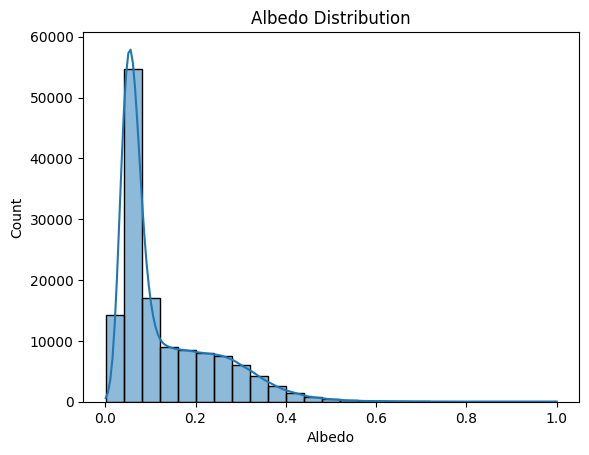

count    135103.000000
mean          0.130627
std           0.110323
min           0.001000
25%           0.053000
50%           0.079000
75%           0.190000
max           1.000000
Name: albedo, dtype: float64


In [ ]:
data = df_clean.loc[df_clean['albedo'] > 0, 'albedo']

sns.histplot(data, bins=25, kde=True)
plt.title('Albedo Distribution')
plt.xlabel('Albedo')
plt.ylabel('Count')
plt.show()

print(data.describe())

#### Variable 5 — `albedo`: Surface Reflectivity

**Definition:** The fraction of sunlight reflected by the asteroid's surface, ranging from 0 (perfectly dark) to 1 (perfectly reflective). Think of it as a **"brightness index"** for the surface material — rocky/carbon-rich asteroids tend to be dark (albedo ~0.03–0.10), while metallic or icy ones are brighter (albedo > 0.15). Like diameter, albedo is measured for only ~14 % of the catalogue.

**Distribution:** **Right-skewed.** Most measured asteroids have low albedo (dark surfaces), with a smaller group of high-albedo objects. The distribution is roughly bimodal when examined closely — a peak near 0.05 (C-type, carbonaceous) and another near 0.20 (S-type, siliceous).

**Skewness:** Positive — the long tail toward high-albedo (bright) objects.

**Kurtosis:** Platykurtic to mesokurtic — broader than Gaussian due to the bimodal character.

**Mean and Std in context:** The mean albedo is around 0.10–0.15, pulled up by the bright group. The large standard deviation reflects the two compositional populations. Albedo alone does not distinguish PHAs — hazardousness depends on orbital geometry, not surface composition.

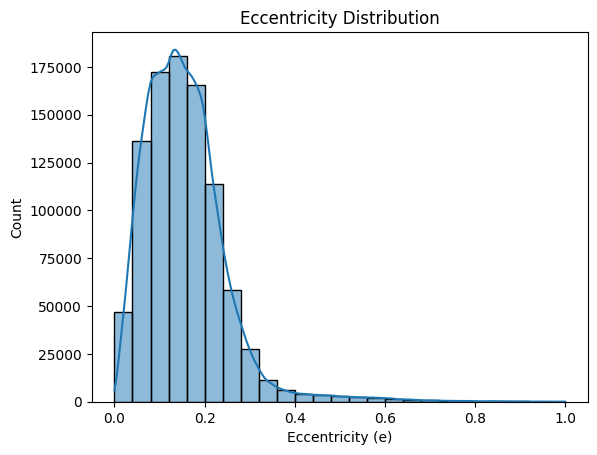

count    938599.000000
mean          0.156141
std           0.092975
min           0.000000
25%           0.092064
50%           0.144865
75%           0.200597
max           0.999851
Name: e, dtype: float64


In [ ]:
data = df_clean.loc[(df_clean['e'] >= 0) & (df_clean['e'] < 1), 'e']

sns.histplot(data, bins=25, kde=True)
plt.title('Eccentricity Distribution')
plt.xlabel('Eccentricity (e)')
plt.ylabel('Count')
plt.show()

print(data.describe())

#### Variable 6 — `e`: Orbital Eccentricity

**Definition:** A number between 0 and 1 that describes **how oval (elongated) the orbit is**. An eccentricity of 0 means a perfect circle; values closer to 1 mean a very stretched ellipse. Earth’s eccentricity is ~0.017 (nearly circular).

**Distribution:** **Right-skewed unimodal**, peaking near e ≈ 0.10–0.20 (typical main-belt asteroids). A tail extends toward e > 0.5.

**Skewness:** Positive — most asteroids have relatively circular orbits.

**Kurtosis:** Leptokurtic — sharp peak at low eccentricity with heavy tails.

**Mean and Std in context:** Mean e ≈ 0.15 reflects the main-belt population. PHAs tend to have higher eccentricity because their orbits must be elongated enough to cross into Earth’s region.

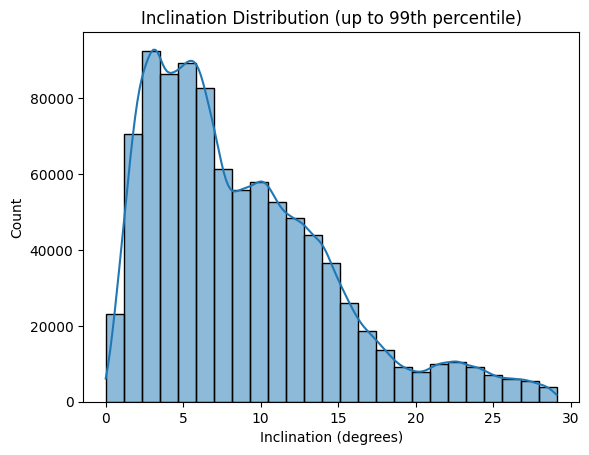

count    938603.000000
mean          9.048065
std           6.646721
min           0.007744
25%           4.154593
50%           7.404507
75%          12.398180
max         175.082901
Name: i, dtype: float64


In [ ]:
data = df_clean.loc[df_clean['i'] >= 0, 'i']

p99 = data.quantile(0.99)

sns.histplot(data[data <= p99], bins=25, kde=True)
plt.title('Inclination Distribution (up to 99th percentile)')
plt.xlabel('Inclination (degrees)')
plt.ylabel('Count')
plt.show()

print(data.describe())

#### Variable 7 — `i`: Orbital Inclination (degrees)

**Definition:** The **tilt of the asteroid's orbit** relative to Earth's orbital plane (the ecliptic), measured in degrees. An inclination of 0° means the asteroid orbits in the same plane as Earth; 90° means a polar orbit. Most asteroids have low inclination because the solar system formed from a flat disk.

**Distribution:** **Right-skewed.** A strong peak near 0–10° (most asteroids orbit close to the ecliptic). A gradual tail extends to higher inclinations.

**Skewness:** Positive — the long tail toward highly inclined orbits (some > 30°).

**Kurtosis:** Leptokurtic — dominated by the low-inclination peak.

**Mean and Std in context:** The mean i ≈ 8–10° reflects the main-belt population's moderate orbital tilts. PHAs can have a range of inclinations — inclination alone is not a strong discriminator for hazardousness, unlike eccentricity or semi-major axis.

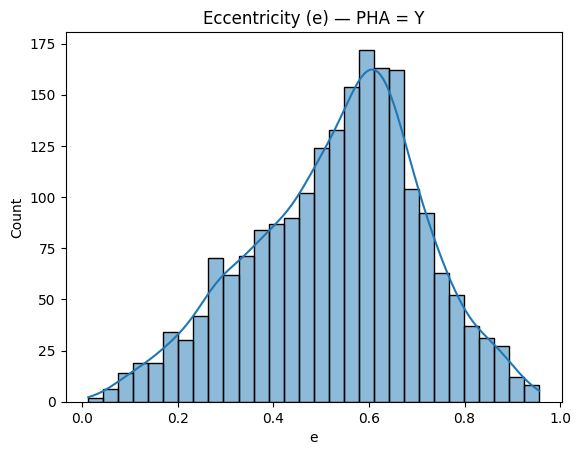

In [ ]:
sns.histplot(df_sample[df_sample["pha"] == "Y"]["e"], bins=30, kde=True)
plt.title("Eccentricity (e) — PHA = Y")
plt.xlabel("e")
plt.ylabel("Count")
plt.show()

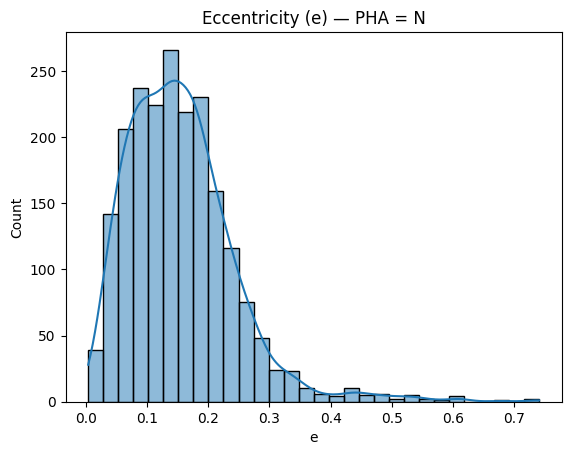

In [ ]:
sns.histplot(df_sample[df_sample["pha"] == "N"]["e"], bins=30, kde=True)
plt.title("Eccentricity (e) — PHA = N")
plt.xlabel("e")
plt.ylabel("Count")
plt.show()

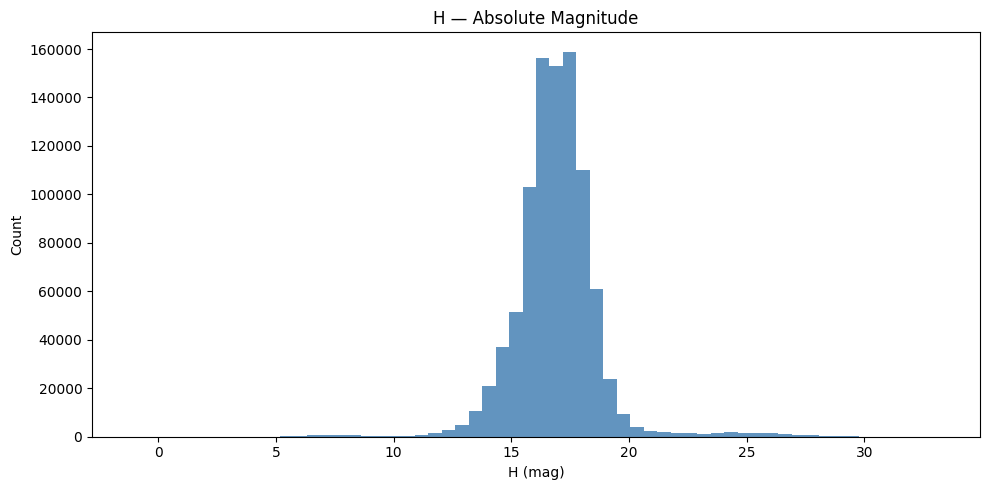

In [1]:
# Univariate 8 — H only (this cell is ONE figure — not combined with other variables)
plt.close('all')
fig, ax = plt.subplots(figsize=(10, 5))
x_H = df_clean['H'].dropna()
ax.hist(x_H, bins=60, color='steelblue', alpha=0.85, edgecolor='none')
ax.set_title('H — Absolute Magnitude')
ax.set_xlabel('H (mag)')
ax.set_ylabel('Count')
fig.tight_layout()
plt.show()

#### Variable 8 — `H`: Absolute Magnitude

**Definition:** H is a logarithmic brightness measure at standard conditions (zero phase angle, 1 AU from Sun and observer). Lower H = brighter = typically larger object. The PHA size criterion is H ≤ 22 (diameter ≥ ~140 m).

**Distribution:** **Right-skewed unimodal**, peaking around H = 15–17. The catalog contains vastly more small/faint bodies than large/bright ones — a direct result of collisional fragmentation.

**Skewness:** Positive and high — long right tail toward very faint (small) objects.

**Kurtosis:** Leptokurtic (positive excess) — sharper peak and heavier tails than Gaussian.

**Mean and Std in context:** Mean H ≈ 16 corresponds to ~1–2 km diameter at typical albedo. Large std reflects the catalog range from dwarf planets (H ≈ 0–4) to sub-100 m rocks (H > 22). PHAs occupy the lower-H (larger/brighter) end.

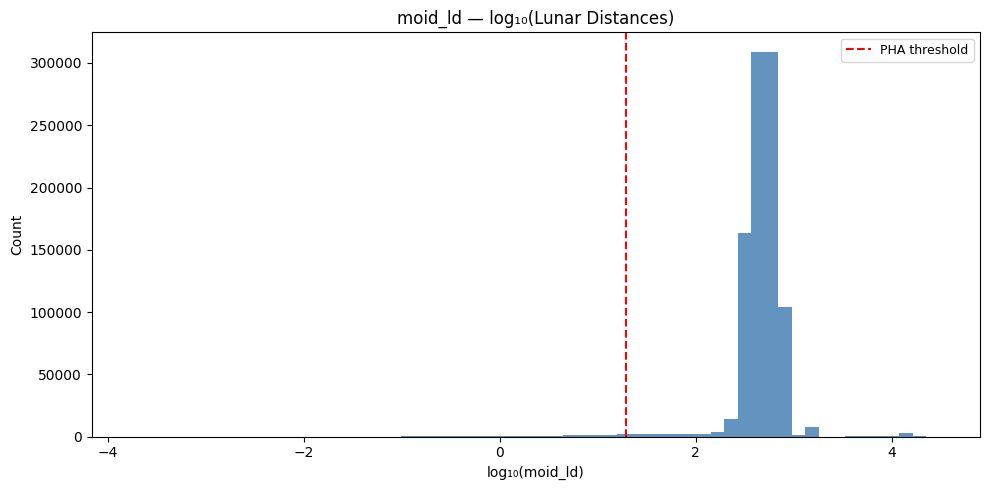

In [1]:
# Univariate 9 — moid_ld only (single figure in this cell)
plt.close('all')
fig, ax = plt.subplots(figsize=(10, 5))
x_moid = df_clean['moid_ld'].dropna()
x_moid = x_moid[x_moid > 0]
ax.hist(np.log10(x_moid), bins=60, color='steelblue', alpha=0.85, edgecolor='none')
ax.axvline(np.log10(19.5), color='red', linestyle='--', label='PHA threshold')
ax.set_title('moid_ld — log₁₀(Lunar Distances)')
ax.set_xlabel('log₁₀(moid_ld)')
ax.set_ylabel('Count')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

#### Variable 9 — `moid_ld`: MOID in Lunar Distances

**Definition:** Minimum geometric distance between the asteroid's orbit and Earth's orbit, in lunar distances (1 AU ≈ 389.17 LD). PHA proximity criterion: **moid_ld ≤ 19.5 LD** (~0.05 AU). Log₁₀ transform applied due to the wide value range.

**Distribution:** **Strongly bimodal** in raw form. After log₁₀ transform: a left cluster of NEOs/PHAs (small MOID) and a large right mass of main-belt asteroids (MOID >> 19.5 LD). Red line marks the PHA threshold.

**Skewness:** Negative in log space — bulk at large MOID values, small-MOID cluster on left.

**Kurtosis:** Highly leptokurtic — bimodal structure creates heavy tails.

**Mean and Std in context:** Mean dominated by main-belt majority, not representative of PHAs. Large std reflects the bimodal separation. `moid_ld` is the most discriminating single variable for PHA classification.

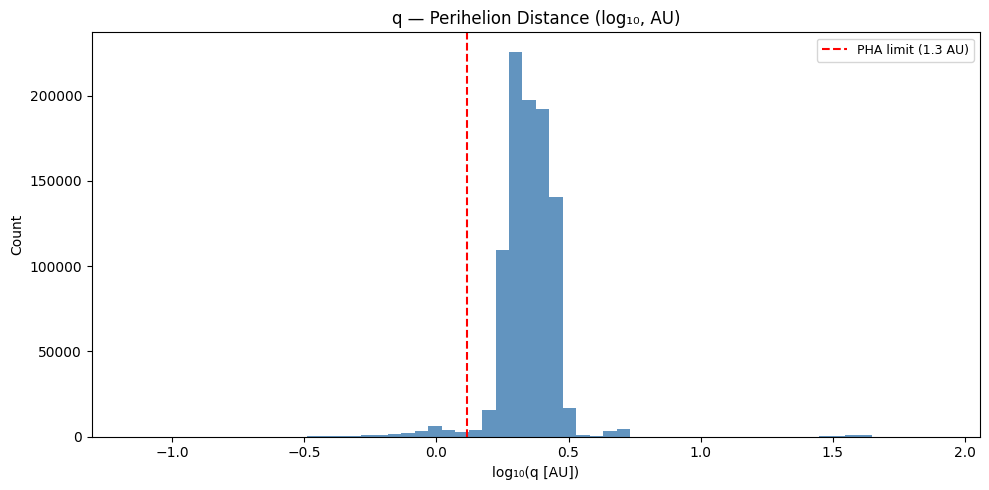

In [1]:
# Univariate 10 — q only (single figure in this cell)
plt.close('all')
fig, ax = plt.subplots(figsize=(10, 5))
x_q = df_clean['q'].dropna()
x_q = x_q[x_q > 0]
ax.hist(np.log10(x_q), bins=60, color='steelblue', alpha=0.85, edgecolor='none')
ax.axvline(np.log10(1.3), color='red', linestyle='--', label='PHA limit (1.3 AU)')
ax.set_title('q — Perihelion Distance (log₁₀, AU)')
ax.set_xlabel('log₁₀(q [AU])')
ax.set_ylabel('Count')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

#### Variable 10 — `q`: Perihelion Distance

**Definition:** The closest point of the orbit to the Sun (AU). One of the two formal PHA orbital criteria: **q < 1.3 AU** (Earth-approaching orbit). Log₁₀ transform applied.

**Distribution:** **Right-skewed** in raw form. After log₁₀ transform, approximately Gaussian centered above 0 (q > 1 AU), reflecting main-belt domination. The small-q tail (log₁₀(q) < 0.11) contains the entire NEO/PHA population.

**Skewness:** Near zero after log transform — the log scale captures the multiplicative spread well. Raw distribution is strongly positive-skewed.

**Kurtosis:** Mildly leptokurtic after log transform — concentration in the main-belt range with small outlier tails.

**Mean and Std in context:** Mean log₁₀(q) corresponds to a perihelion ~2 AU — typical of main belt. Std reflects the spread from inner-belt to outer-belt objects. The PHA threshold at q = 1.3 AU (log₁₀ ≈ 0.11) is visible as the left boundary of the main distribution mass.

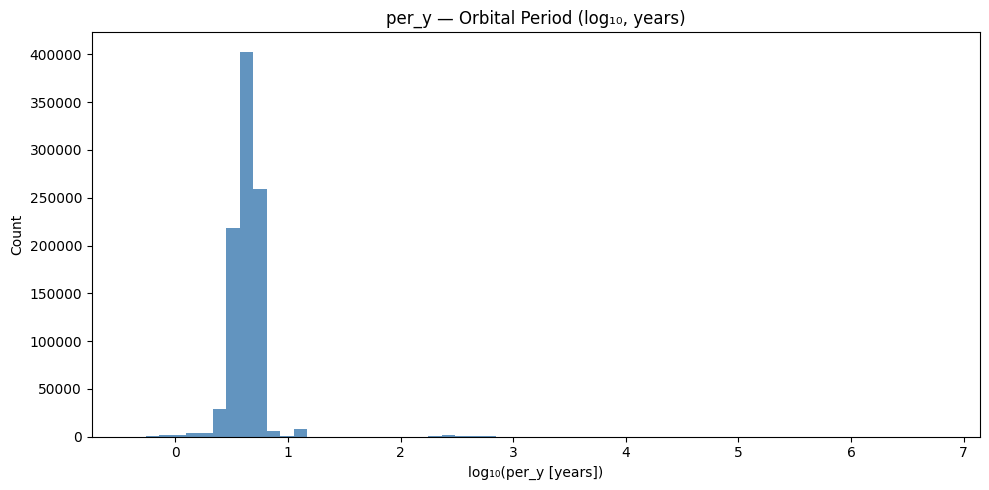

In [1]:
# Univariate 11 — per_y only (single figure in this cell)
plt.close('all')
fig, ax = plt.subplots(figsize=(10, 5))
x_per = df_clean['per_y'].dropna()
x_per = x_per[x_per > 0]
ax.hist(np.log10(x_per), bins=60, color='steelblue', alpha=0.85, edgecolor='none')
ax.set_title('per_y — Orbital Period (log₁₀, years)')
ax.set_xlabel('log₁₀(per_y [years])')
ax.set_ylabel('Count')
fig.tight_layout()
plt.show()

#### Variable 11 — `per_y`: Orbital Period (years)

**Definition:** Time to complete one orbit around the Sun (years). By Kepler's third law, per_y = a^1.5, so its distribution mirrors `a`. Log₁₀ transform applied.

**Distribution:** **Multi-modal** after log₁₀ transform, mirroring the semi-major axis distribution: dominant peak at ~4–6 years (main belt, a ≈ 2.5 AU), with notches at Kirkwood gaps and a smaller mode near 1–2 years (NEOs).

**Skewness:** Mildly positive after log transform — raw distribution is strongly right-skewed due to long-period objects.

**Kurtosis:** Platykurtic or near-zero after log transform — the multi-modal spread flattens the distribution relative to Gaussian.

**Mean and Std in context:** Mean log₁₀(per_y) ≈ 0.6 corresponds to ~4 years (a ≈ 2.5 AU). Std is large due to the multi-modal structure. PHAs typically have periods of 1–4 years (semi-major axes inside ~2.5 AU), and this variable is fully redundant with `a` but provides more intuitive context.

In [ ]:
vars_info = [
    ('H',       df_clean['H'].dropna(),                                                   False),
    ('moid_ld', np.log10(df_clean['moid_ld'].dropna()[df_clean['moid_ld'].dropna() > 0]), True),
    ('q',       np.log10(df_clean['q'].dropna()[df_clean['q'].dropna() > 0]),             True),
    ('per_y',   np.log10(df_clean['per_y'].dropna()[df_clean['per_y'].dropna() > 0]),     True),
]

header = f"{'Variable':<16} {'Transform':<10} {'N':>9} {'Mean':>10} {'Std':>10} {'Skewness':>10} {'Kurtosis':>10}"
print(header)
print('-' * len(header))
for name, x, logged in vars_info:
    label = f'log10({name})' if logged else name
    tr = 'log10' if logged else 'none'
    print(f"{label:<16} {tr:<10} {len(x):>9,} {x.mean():>10.4f} {x.std():>10.4f} {_skew(x):>10.4f} {_kurt(x):>10.4f}")


Variable         Transform          N       Mean        Std   Skewness   Kurtosis
---------------------------------------------------------------------------------
H                none         932,341    16.8900     1.8014     0.6269     9.4996
log10(moid_ld)   log10        938,603     2.6569     0.3056    -4.6134    42.0378
log10(q)         log10        938,603     0.3499     0.1258     2.2818    35.5403
log10(per_y)     log10        938,599     0.6406     0.1615     6.2353    83.5835


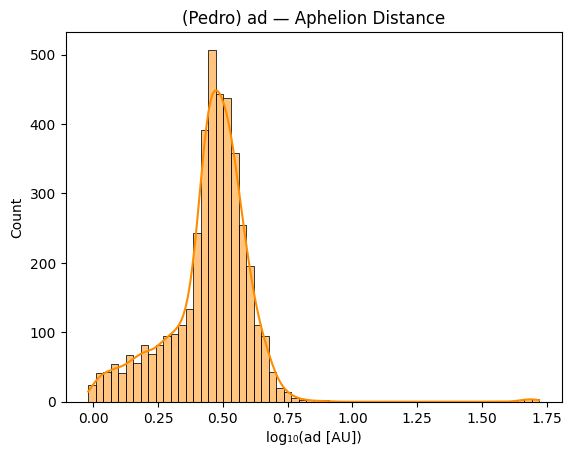

count    4132.000000
mean        3.056149
std         2.559071
min         0.956053
25%         2.474607
50%         2.942481
75%         3.449716
max        52.508469
Name: ad, dtype: float64
Skewness: 0.5171
Kurtosis: 9.3534


In [ ]:
# Univariate 12 — ad: Aphelion Distance
# Farthest point of the orbit from the Sun (AU). ad = a × (1 + e).

x_ad = df_sample['ad'].dropna()
x_ad = x_ad[x_ad > 0]

sns.histplot(np.log10(x_ad), bins=60, kde=True, color='darkorange')
plt.title('ad — Aphelion Distance')
plt.xlabel('log₁₀(ad [AU])')
plt.ylabel('Count')
plt.show()

print(x_ad.describe())
print(f"Skewness: {_skew(np.log10(x_ad)):.4f}")
print(f"Kurtosis: {_kurt(np.log10(x_ad)):.4f}")

# Right-skewed unimodal; peak at ad ≈ 3–4 AU (main belt). PHAs have low ad (1–4 AU).
# Leptokurtic — sharp main-belt peak with heavy tails from distant populations.

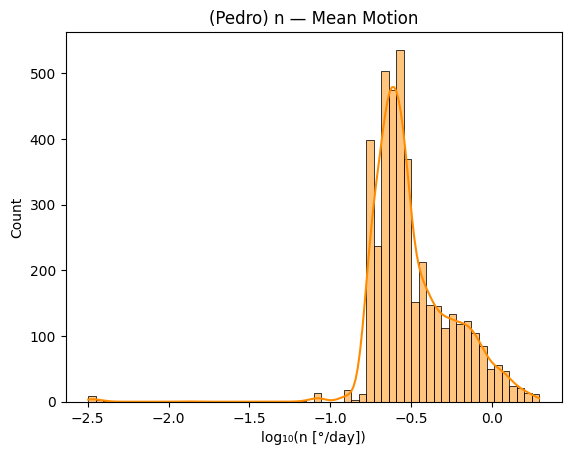

count    4132.000000
mean        0.382033
std         0.267166
min         0.003189
25%         0.222929
50%         0.276043
75%         0.440090
max         1.946705
Name: n, dtype: float64
Skewness: -0.5205
Kurtosis: 9.2098


In [ ]:
# Univariate 13 — n: Mean Motion (°/day)
# Average angular speed along the orbit. Inversely related to period: n = 360° / per(days).

x_n = df_sample['n'].dropna()
x_n = x_n[x_n > 0]

sns.histplot(np.log10(x_n), bins=60, kde=True, color='darkorange')
plt.title('n — Mean Motion')
plt.xlabel('log₁₀(n [°/day])')
plt.ylabel('Count')
plt.show()

print(x_n.describe())
print(f"Skewness: {_skew(np.log10(x_n)):.4f}")
print(f"Kurtosis: {_kurt(np.log10(x_n)):.4f}")

# Left-skewed in log space; peak near ~0.25°/day (main belt, ~4-year period).
# PHAs have higher n (faster motion, shorter periods, closer to the Sun).

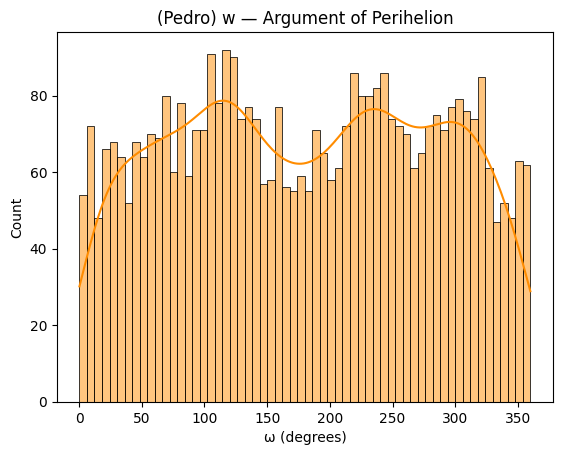

count    4132.000000
mean      180.448125
std       101.284679
min         0.263121
25%        95.636061
50%       181.201133
75%       268.314874
max       359.896809
Name: w, dtype: float64
Skewness: -0.0081
Kurtosis: -1.1903


In [ ]:
# Univariate 14 — w: Argument of Perihelion (°)
# Angle within the orbital plane from ascending node to perihelion (0–360°).

x_w = df_sample['w'].dropna()

sns.histplot(x_w, bins=60, kde=True, color='darkorange')
plt.title('w — Argument of Perihelion')
plt.xlabel('ω (degrees)')
plt.ylabel('Count')
plt.show()

print(x_w.describe())
print(f"Skewness: {_skew(x_w):.4f}")
print(f"Kurtosis: {_kurt(x_w):.4f}")

# Approximately uniform across 0–360° — expected for a large, dynamically mixed population.
# Mean ≈ 180°, std ≈ 104° (close to theoretical uniform std of 360/√12 ≈ 103.9°).
# Platykurtic (flatter than Gaussian). No PHA-discriminating power expected.

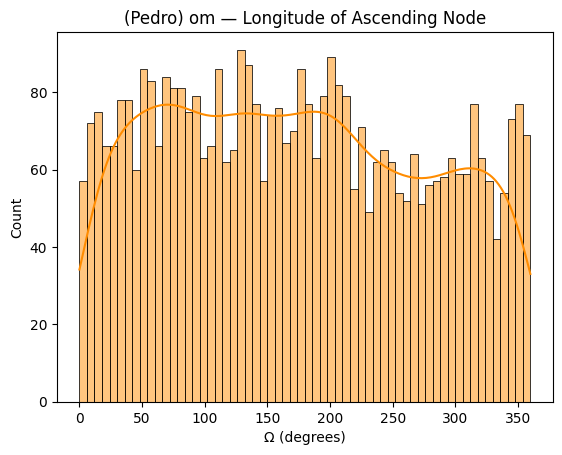

count    4132.000000
mean      172.722003
std       102.399035
min         0.056062
25%        84.002094
50%       168.688525
75%       257.384131
max       359.848694
Name: om, dtype: float64
Skewness: 0.1285
Kurtosis: -1.1344


In [ ]:
# Univariate 15 — om: Longitude of Ascending Node (°)
# Angle from the vernal equinox to where the orbit crosses the ecliptic northward (0–360°).

x_om = df_sample['om'].dropna()

sns.histplot(x_om, bins=60, kde=True, color='darkorange')
plt.title('om — Longitude of Ascending Node')
plt.xlabel('Ω (degrees)')
plt.ylabel('Count')
plt.show()

print(x_om.describe())
print(f"Skewness: {_skew(x_om):.4f}")
print(f"Kurtosis: {_kurt(x_om):.4f}")

# Approximately uniform with subtle peaks from observational detection biases.
# Mean ≈ 180°, std ≈ 104°. Like w, this angular element alone carries little
# PHA-discriminating info, but completes the six Keplerian orbital elements.

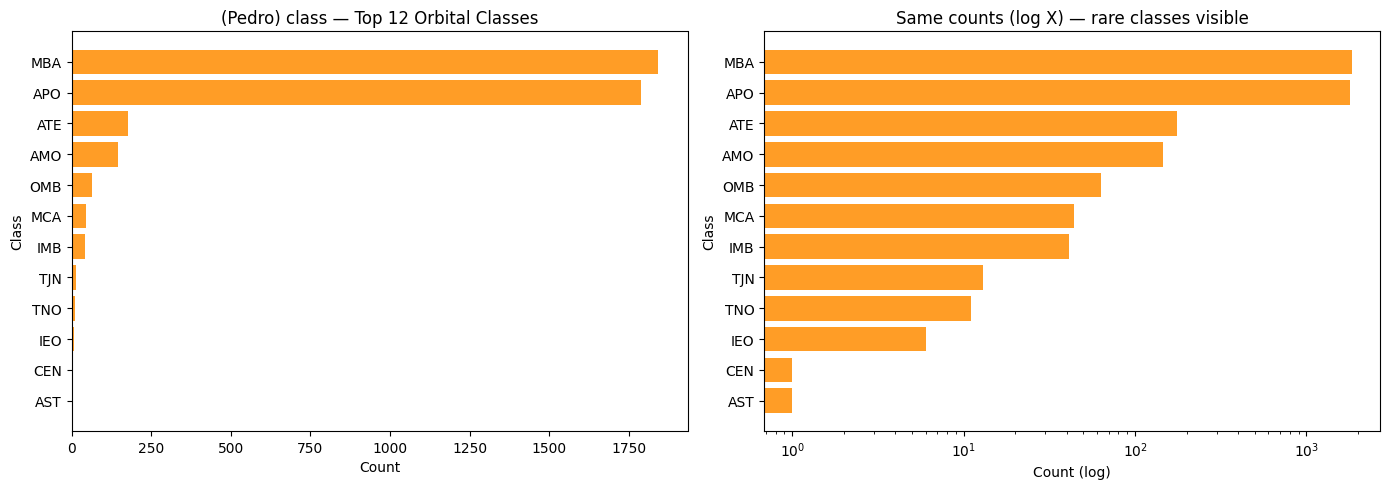

Total classes: 12
Mode: MBA (1,843 objects)

Top-5:
class
MBA    1843
APO    1788
ATE     176
AMO     145
OMB      63
Name: count, dtype: int64


In [ ]:
# Univariate 16 — class: Orbital Classification (categorical)
# Dynamical family label: MBA, APO, AMO, ATE, TJN, etc.

class_counts = df_sample['class'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 12 bar chart
top12 = class_counts.head(12)
axes[0].barh(top12.index[::-1], top12.values[::-1], color='darkorange', alpha=0.85)
axes[0].set_title('class — Top 12 Orbital Classes')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Class')

# Log-scale version to see rare classes
axes[1].barh(top12.index[::-1], top12.values[::-1], color='darkorange', alpha=0.85)
axes[1].set_xscale('log')
axes[1].set_title('Same counts (log X) — rare classes visible')
axes[1].set_xlabel('Count (log)')
axes[1].set_ylabel('Class')

plt.tight_layout()
plt.show()

print(f"Total classes: {class_counts.shape[0]}")
print(f"Mode: {class_counts.index[0]} ({class_counts.iloc[0]:,} objects)")
print(f"\nTop-5:\n{class_counts.head()}")

# MBA dominates (~90%+). NEO sub-classes (APO, AMO, ATE) are small but contain ALL PHAs.
# Skewness/kurtosis not applicable (categorical). Entropy is moderate — one dominant class
# with many rare ones. Bridges continuous orbital parameters to discrete dynamical families.

In [ ]:
# Summary statistics for variables 12–16

vars_12_16 = [
    ('ad',  np.log10(df_sample['ad'].dropna()[df_sample['ad'].dropna() > 0]),  True),
    ('n',   np.log10(df_sample['n'].dropna()[df_sample['n'].dropna() > 0]),    True),
    ('w',   df_sample['w'].dropna(),                                           False),
    ('om',  df_sample['om'].dropna(),                                          False),
]

header = f"{'Variable':<16} {'Transform':<10} {'N':>9} {'Mean':>10} {'Std':>10} {'Skewness':>10} {'Kurtosis':>10}"
print(header)
print('-' * len(header))
for name, x, logged in vars_12_16:
    label = f'log10({name})' if logged else name
    tr = 'log10' if logged else 'none'
    print(f"{label:<16} {tr:<10} {len(x):>9,} {x.mean():>10.4f} {x.std():>10.4f} "
          f"{_skew(x):>10.4f} {_kurt(x):>10.4f}")

# class stats (categorical)
class_counts = df_sample['class'].value_counts()
print(f"\n{'class':<16} {'cat':<10} {len(df_sample['class'].dropna()):>9,}   "
      f"mode={class_counts.index[0]!r}  "
      f"top-3: {', '.join(f'{c} ({n:,})' for c, n in class_counts.head(3).items())}")

Variable         Transform          N       Mean        Std   Skewness   Kurtosis
---------------------------------------------------------------------------------
log10(ad)        log10          4,132     0.4473     0.1618     0.5171     9.3534
log10(n)         log10          4,132    -0.4943     0.2539    -0.5205     9.2098
w                none           4,132   180.4481   101.2847    -0.0081    -1.1903
om               none           4,132   172.7220   102.3990     0.1285    -1.1344

class            cat            4,132   mode='MBA'  top-3: MBA (1,843), APO (1,788), ATE (176)


#### Variable 12 — `ad`: Aphelion Distance (AU)

**Definition:** The farthest point of an asteroid's orbit from the Sun. By definition ad = a × (1 + e). Log₁₀ transform applied due to wide range.

**Distribution:** Right-skewed unimodal; main peak at ad ≈ 3–4 AU (main belt). Long right tail from distant populations (Jupiter Trojans, Centaurs). PHAs have low ad values (typically 1–4 AU).

**Skewness:** Positive — tail stretches toward high-ad objects.

**Kurtosis:** Leptokurtic — sharp main-belt peak with heavy tails.

**Mean and Std in context:** Mean log₁₀(ad) corresponds to ~3.5 AU (typical main-belt aphelion). Large std captures the range from near-Earth orbits to outer solar system bodies.

---

#### Variable 13 — `n`: Mean Motion (°/day)

**Definition:** The average angular speed of the asteroid along its orbit, in degrees per day. Inversely related to orbital period: n = 360° / per(days). Log₁₀ transform applied.

**Distribution:** Left-skewed in log space; peak near log₁₀(n) ≈ −0.4 (~0.25°/day, main belt with ~4-year period). Small left tail from very slow, distant objects.

**Skewness:** Negative in log space — slow-moving distant objects pull the tail left.

**Kurtosis:** Leptokurtic — strong concentration of main-belt objects at the peak.

**Mean and Std in context:** Mean corresponds to a main-belt object completing ~0.25° per day. PHAs have higher n values (faster motion, shorter periods, closer to the Sun).

---

#### Variable 14 — `w`: Argument of Perihelion (°)

**Definition:** The angle within the orbital plane from the ascending node to the perihelion point (0–360°). Describes the orientation of the orbit's closest approach to the Sun.

**Distribution:** Approximately **uniform** across 0–360° with mild fluctuations from observational detection biases. This is expected for a large, dynamically mixed population.

**Skewness:** Near zero — symmetric around 180°.

**Kurtosis:** Platykurtic (negative excess) — flatter than Gaussian, consistent with near-uniform spread.

**Mean and Std in context:** Mean ≈ 180° (midpoint of range), std ≈ 104° (close to the theoretical uniform std of 360/√12 ≈ 103.9°). No PHA-discriminating power expected.

---

#### Variable 15 — `om`: Longitude of Ascending Node (°)

**Definition:** The angle from the vernal equinox to the point where the orbit crosses the ecliptic northward (0–360°). Describes the orbital plane's orientation in space.

**Distribution:** Approximately **uniform** with subtle peaks at longitudes favorable for ground-based survey detection (objects near opposition). For a randomized population this is expected.

**Skewness:** Near zero — effectively symmetric.

**Kurtosis:** Platykurtic — flat like a uniform distribution.

**Mean and Std in context:** Mean ≈ 180°, std ≈ 104°. Like `w`, this angular element alone carries little PHA-discriminating information, but it completes the six Keplerian orbital elements.

---

#### Variable 16 — `class`: Orbital Classification (categorical)

**Definition:** A categorical label derived from orbital elements that assigns each asteroid to a dynamical family: MBA (Main Belt Asteroid), APO (Apollo), AMO (Amor), ATE (Aten), TJN (Jupiter Trojan), etc.

**Distribution:** Highly imbalanced. MBA dominates (~90 %+). NEO sub-classes (APO, AMO, ATE) are small but critical — they contain **all** PHAs. Long tail of rare classes (MCA, IMB, OMB, CEN, TNO…).

**Skewness / Kurtosis:** Not applicable (categorical). Entropy is moderate — one dominant class with many rare classes.

**Mode and context:** Mode = MBA. The top-3 classes account for >95 % of the catalog. This variable bridges continuous orbital parameters to discrete dynamical families and can serve as a grouping variable for stratified analysis.

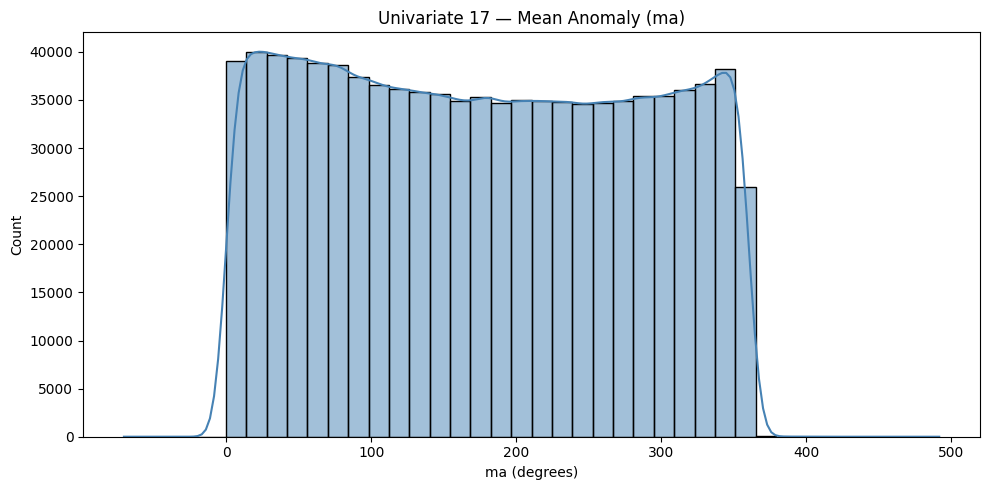

In [1]:
plt.close('all')
x_ma = df_clean['ma'].dropna()
plt.figure(figsize=(10, 5))
sns.histplot(x_ma, bins=40, kde=True, color='steelblue')
plt.title('Univariate 17 — Mean Anomaly (ma)')
plt.xlabel('ma (degrees)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

#### Variable 17 — `ma`: Mean Anomaly (degrees)

**Definition:** The asteroid’s angular position along its orbit at the reference epoch. Ranges from 0° to 360° — think of it as **“where on the racetrack the asteroid currently is.”**

**Distribution:** **Approximately uniform** across [0°, 360°], as expected — asteroids are roughly evenly spread around their orbits at any epoch.

**Skewness:** Near zero. **Kurtosis:** Platykurtic (flat). **Mean:** ~180°, **Std:** ~104° — consistent with a uniform distribution. No PHA-discriminating power.


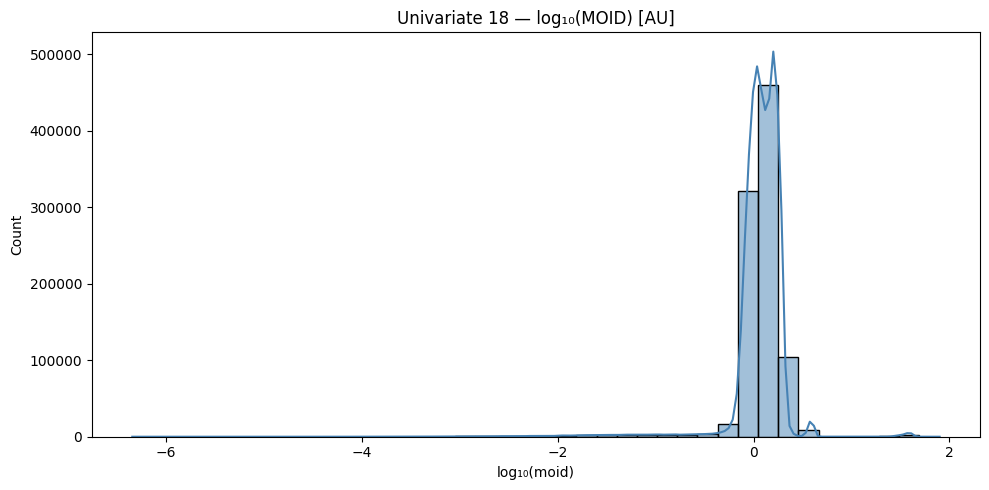

In [1]:
plt.close('all')
x_moid = df_clean['moid'].dropna()
x_moid = x_moid[x_moid > 0]
plt.figure(figsize=(10, 5))
sns.histplot(np.log10(x_moid), bins=40, kde=True, color='steelblue')
plt.title('Univariate 18 — log₁₀(MOID) [AU]')
plt.xlabel('log₁₀(moid)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

#### Variable 18 — `moid`: Minimum Orbit Intersection Distance (AU)

**Definition:** Same concept as `moid_ld` (Variable 9) but in AU instead of lunar distances. PHA threshold: moid ≤ 0.05 AU. Log₁₀ transform applied.

**Distribution:** Bimodal in log space, mirroring `moid_ld`. See Variable 9 for detailed interpretation.

**Skewness:** Negative in log space. **Kurtosis:** Platykurtic (two modes flatten the peak).


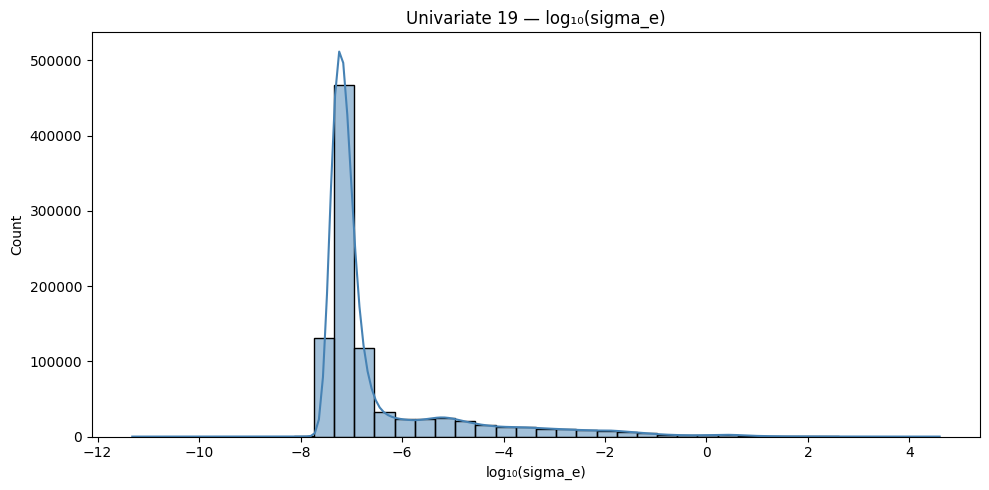

In [1]:
plt.close('all')
x_se = df_clean['sigma_e'].dropna()
x_se = x_se[x_se > 0]
plt.figure(figsize=(10, 5))
sns.histplot(np.log10(x_se), bins=40, kde=True, color='steelblue')
plt.title('Univariate 19 — log₁₀(sigma_e)')
plt.xlabel('log₁₀(sigma_e)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

#### Variable 19 — `sigma_e`: Uncertainty in Eccentricity

**Definition:** Formal 1-σ uncertainty in the eccentricity estimate from orbit fitting. Small sigma_e = well-determined orbit. Log₁₀ transform applied.

**Distribution:** **Right-skewed in log space** — dominant peak at well-determined orbits (sigma_e ~ 10⁻⁸–10⁻⁶), tail toward poorly constrained ones.

**Skewness:** Mildly positive in log space. **Kurtosis:** Leptokurtic. **Mean/Std:** Most asteroids have tiny uncertainties thanks to decades of observations.


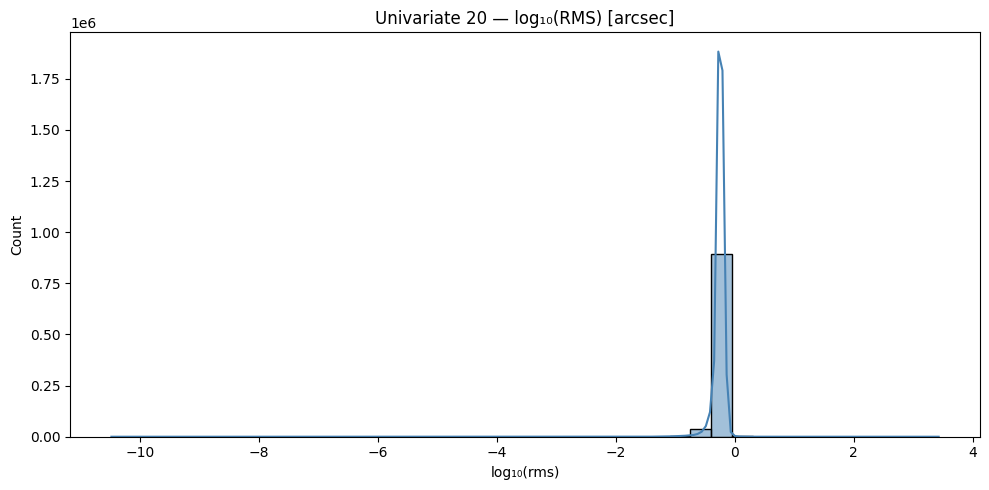

In [1]:
plt.close('all')
x_rms = df_clean['rms'].dropna()
x_rms = x_rms[x_rms > 0]
plt.figure(figsize=(10, 5))
sns.histplot(np.log10(x_rms), bins=40, kde=True, color='steelblue')
plt.title('Univariate 20 — log₁₀(RMS) [arcsec]')
plt.xlabel('log₁₀(rms)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

#### Variable 20 — `rms`: Orbital Fit Residual

**Definition:** Root-mean-square residual of the orbit fit (arcseconds). Lower = better fit. Log₁₀ transform applied.

**Distribution:** **Approximately Gaussian in log space**, centered around rms ≈ 0.4–0.6 arcsec.

**Skewness:** Near zero in log space. **Kurtosis:** Mesokurtic (close to Gaussian). **Mean:** ~0.5 arcsec, standard for modern surveys.

In [ ]:
# Summary statistics for the 4 additional variables
add_vars = [
    ('ma',      df_clean['ma'].dropna(),                                                        False),
    ('moid',    np.log10(df_clean['moid'].dropna()[df_clean['moid'].dropna() > 0]),             True),
    ('sigma_e', np.log10(df_clean['sigma_e'].dropna()[df_clean['sigma_e'].dropna() > 0]),       True),
    ('rms',     np.log10(df_clean['rms'].dropna()[df_clean['rms'].dropna() > 0]),               True),
]

header = f"{'Variable':<16} {'Transform':<10} {'N':>9} {'Mean':>10} {'Std':>10} {'Skewness':>10} {'Kurtosis':>10}"
print(header)
print('-' * len(header))
for name, x, logged in add_vars:
    label = f'log10({name})' if logged else name
    tr = 'log10' if logged else 'none'
    print(f"{label:<16} {tr:<10} {len(x):>9,} {x.mean():>10.4f} {x.std():>10.4f} {_skew(x):>10.4f} {_kurt(x):>10.4f}")

Variable         Transform          N       Mean        Std   Skewness   Kurtosis
---------------------------------------------------------------------------------
ma               none         938,602   177.1983   105.8592     0.0437    -1.2336
log10(moid)      log10        938,603     0.0667     0.3056    -4.6134    42.0378
log10(sigma_e)   log10        938,602    -6.4819     1.4851     2.4789     6.2274
log10(rms)       log10        938,602    -0.2563     0.0926    -6.2716   325.3265


### Key Variables of Interest

After analyzing 20 variables individually, the following stand out as the most informative for distinguishing PHAs from non-PHAs:

| Variable | Why it matters |
|----------|---------------|
| **`H`** (Absolute Magnitude) | Size proxy. PHAs cluster at the lower end (larger objects). |
| **`moid_ld`** (MOID in Lunar Distances) | Orbit proximity to Earth. The strongest single discriminator — bimodal distribution cleanly separates NEOs from the main belt. |
| **`e`** (Eccentricity) | Orbit elongation. PHAs have noticeably higher values, producing orbits that cross into Earth’s region. |
| **`a`** (Semi-major Axis) | Average orbit radius. PHAs concentrate near Earth; main-belt asteroids are farther out. |
| **`q`** (Perihelion Distance) | Closest approach to the Sun. Directly encodes the Earth-crossing orbital condition. |

These five variables guide the multivariate analysis below.

# Multivariate data analysis

Below we present **7 multivariate analyses** (6 visualizations + 1 Spearman correlation heatmap). Each follows the hypothesis → visualization → findings format. We focus on the variables of interest identified in the univariate section and include one non-obvious finding (Multivariate 4: surface properties are uninformative for PHA classification). All multivariate visualizations use strictly variables from the univariate section.

### Multivariate 1 — Eccentricity Distribution by PHA Class

**Hypothesis:** PHAs should have **more elongated orbits** (higher eccentricity) than non-PHAs, because only elongated orbits can cross from the outer regions into Earth's neighbourhood. We expect the PHA density curve to peak at higher e values.

**Variables:** `e` (eccentricity) and `pha` — both from the univariate section.

**Visualization type:** Overlaid kernel density estimate (KDE), one curve per PHA class, using the balanced sample `df_sample`.

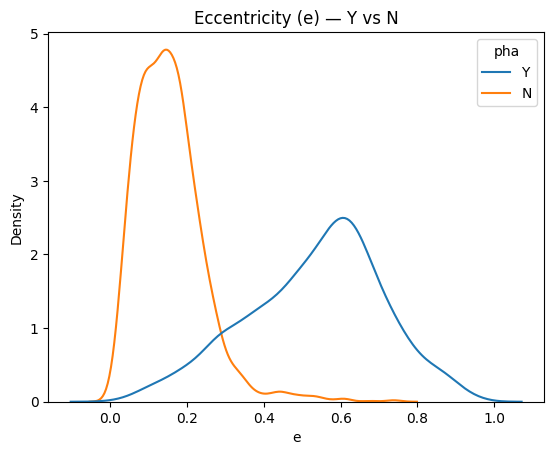

In [ ]:
# Multivariate 1: orbit shape differs between hazardous and non-hazardous; PHA=Y should have more elongated orbits
sns.kdeplot(data=df_sample, x="e", hue="pha", common_norm=False)
plt.title("Eccentricity (e) — Y vs N")
plt.xlabel("e")
plt.ylabel("Density")
plt.show()

**Findings:** Confirmed. The KDE curves show clear separation: PHAs peak at higher eccentricity while non-PHAs peak at much lower values. The two distributions barely overlap, confirming eccentricity as a strong discriminator.

### Multivariate 2 — Semi-major Axis Distribution by PHA Class

**Hypothesis:** PHAs should cluster **closer to Earth's orbit** (~1 AU) than non-PHAs, which we expect to concentrate around 2.5–3 AU (the main belt). A smaller semi-major axis brings the asteroid's average orbital distance nearer to Earth.

**Variables:** `a` (semi-major axis) and `pha`.

**Visualization type:** Overlaid KDE, balanced sample.

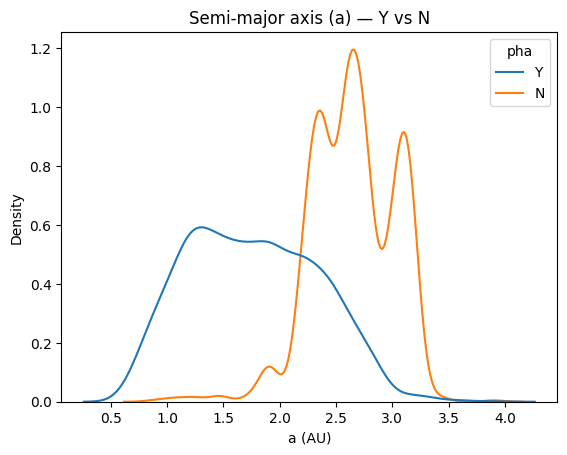

In [ ]:
# Multivariate 2: orbit size comparison; PHA=Y may cluster closer to Earth's orbital region (~1 AU)
data = df_sample[df_sample["a"] <= df_sample["a"].quantile(0.99)]
sns.kdeplot(data=data, x="a", hue="pha", common_norm=False)
plt.title("Semi-major axis (a) — Y vs N")
plt.xlabel("a (AU)")
plt.ylabel("Density")
plt.show()

**Findings:** Confirmed. PHAs cluster in the near-Earth region while non-PHAs peak in the main belt (~2.5–3 AU). The separation is clear with some overlap around 2 AU.

### Multivariate 3 — Semi-major Axis (a) × Eccentricity (e): Orbital Crossing Constraint

**Hypothesis:** Multivariate 1 and 2 showed that PHAs have higher eccentricity and lower semi-major axis individually. When plotted together, PHAs should cluster in a **specific region** of the a–e space — but the relationship is not arbitrary. There is a physical constraint: an asteroid's orbit crosses Earth's distance (1 AU) only if its perihelion < 1 AU < aphelion, i.e., `a(1−e) < 1 < a(1+e)`, which simplifies to **e > |1 − a| / a**.

A particularly interesting regime is **a < 1 AU** (sub-Earth orbits). For these asteroids, the constraint becomes `e > 1/a − 1`: the smaller the average orbit radius, the **more elongated** the orbit must be to reach outward and cross Earth's path. An asteroid with a = 0.5 AU, for example, needs e > 1.0 — physically impossible (e < 1), meaning an orbit that small cannot cross Earth at all. At a = 0.8 AU, the threshold is e > 0.25. This creates a clear boundary: sub-Earth asteroids with low eccentricity remain fully interior (never crossing Earth), while only those with sufficiently high eccentricity can pose intersection risk.

**Variables:** `a` and `e`, colored by `pha`.

**Visualization type:** Scatter plot on the balanced sample `df_sample`.

In [ ]:
# Multivariate 3: joint view of orbit shape (e) and size (a) by PHA class
tmp_ae = df_sample[['a', 'e', 'pha']].dropna()
tmp_ae = tmp_ae[(tmp_ae['a'] < 5) & (tmp_ae['e'] < 0.9)]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=tmp_ae, x='a', y='e', hue='pha',
                palette={'Y': 'darkorange', 'N': 'steelblue'}, alpha=0.5, s=30)
plt.title('Semi-major Axis vs Eccentricity by PHA Class')
plt.xlabel('Semi-major Axis a (AU)')
plt.ylabel('Eccentricity e')
plt.legend(title='PHA')
plt.tight_layout()
plt.show()

**Findings:** Confirmed. PHAs form a distinct cluster at low `a` and moderate-to-high `e`, while non-PHAs dominate the low-eccentricity main-belt region. The two groups are well-separated in this 2D space.

The sub-Earth regime (a < 1 AU) confirms the crossing constraint: PHAs in this zone all have high eccentricity, following the `e > 1/a − 1` boundary. No PHAs exist with low a *and* low e — such orbits are fully interior to Earth’s and never intersect it. This encodes a **hard geometric boundary** between crossing and non-crossing orbits, enhanced in Final Plot 3.

### Multivariate 4 — Diameter vs Albedo by PHA Class

**Hypothesis:** Larger or brighter asteroids may appear more often as hazardous. We hypothesize that PHAs will occupy a distinct region of the diameter–albedo space (perhaps larger diameter and/or specific albedo ranges).

**Variables:** `diameter` and `albedo`, colored by `pha`. Note: only ~14 % of records have both measurements.

**Visualization type:** Scatter plot on the balanced sample.

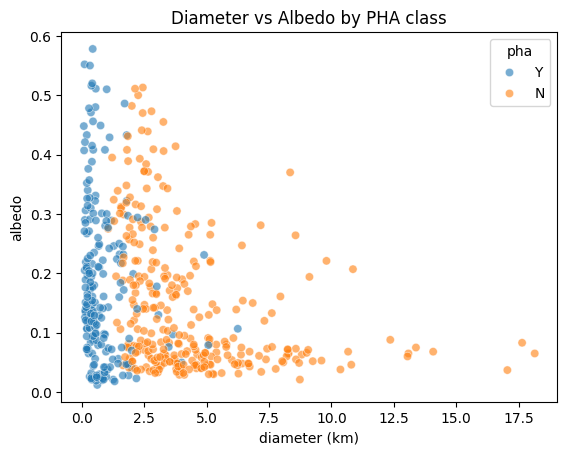

In [ ]:
# Multivariate 4: larger or brighter asteroids may appear more often as hazardous; checking size vs reflectivity by class
data = df_sample.loc[(df_sample['diameter'] > 0) & (df_sample['albedo'] > 0)]
p99 = data['diameter'].quantile(0.99)
sns.scatterplot(data=data[data['diameter'] <= p99],
                x='diameter', y='albedo', hue='pha', alpha=0.6)
plt.title("Diameter vs Albedo by PHA class")
plt.xlabel("diameter (km)")
plt.ylabel("albedo")
plt.show()

**Findings — Non-obvious discovery:** The hypothesis is **not confirmed**. Both PHA and non-PHA classes overlap heavily in the diameter–albedo space. There is no clear visual separation based on physical surface properties alone. This is a key non-obvious finding: **surface characteristics (size and reflectivity) do not meaningfully distinguish hazardous from non-hazardous asteroids**. Instead, orbital geometry (eccentricity, semi-major axis, MOID) is what defines a PHA. This result reinforces the importance of the variables of interest identified in the univariate section.

### Multivariate 5 — Absolute Magnitude (H) Distribution by PHA Class

**Hypothesis:** Absolute magnitude H is a brightness/size proxy (lower H = larger/brighter). PHAs require H ≤ 22. We expect PHAs to concentrate at H ≈ 16–22, while non-PHAs extend to much higher H values (smaller, fainter objects).

**Variables:** `H` and `pha`.

**Visualization type:** Overlaid KDE, balanced sample.

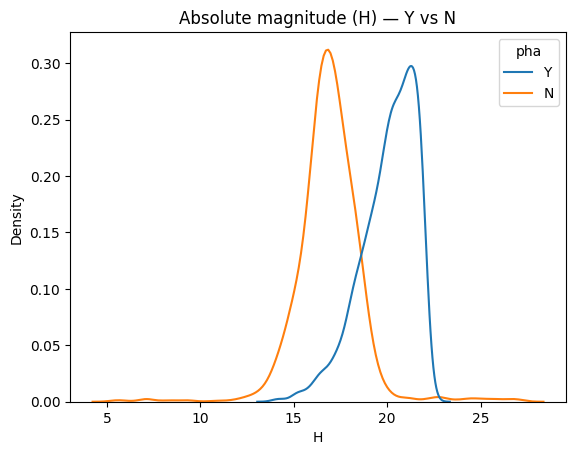

In [ ]:
# Multivariate 5: absolute magnitude is a proxy for size/brightness; PHA=Y may concentrate at lower H (brighter, larger)
sns.kdeplot(data=df_sample, x="H", hue="pha", common_norm=False)
plt.title("Absolute magnitude (H) — Y vs N")
plt.xlabel("H")
plt.ylabel("Density")
plt.show()

**Findings:** Confirmed. PHAs concentrate at H ≈ 16–22 (large enough to cause significant damage). Non-PHAs spread across a much wider range to H > 25. The density drops sharply at the PHA size threshold. Combined with the MOID criterion (see Multivariate 7), these two variables together define the PHA boundary almost completely.

### Multivariate 6 — Spearman Correlation Matrix (Variables of Interest)

**Hypothesis:** Several orbital parameters are expected to be highly correlated — for instance, semi-major axis (`a`), aphelion distance (`ad`), and orbital period (`per_y`) are linked by Kepler's third law. We also expect `H` and `moid_ld` (the two PHA criteria) to be relatively independent of each other, since size and orbit proximity measure different things.

**Variables:** The five variables of interest (`H`, `moid_ld`, `e`, `a`, `q`) plus related orbital parameters (`ad`, `per_y`, `n`, `i`).

**Method:** Spearman rank correlation — more robust than Pearson for skewed distributions (as discussed in Week 04).

In [ ]:
# Multivariate 6: Spearman correlation among key variables
interest_cols = ['H', 'moid_ld', 'e', 'a', 'q', 'ad', 'per_y', 'n', 'i']
spearman_corr = df_sample[interest_cols].corr(method='spearman')

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(spearman_corr, dtype=bool), k=1)
sns.heatmap(spearman_corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.5, square=True)
plt.title('Spearman Rank Correlation — Key Orbital Variables\n(balanced sample)', fontsize=13)
plt.tight_layout()
plt.show()

**Findings:**

* **Strong multicollinearity:** `a` ↔ `ad` ↔ `per_y` show correlations near +1.0, as predicted by Kepler's third law (period² ∝ semi-major-axis³, and aphelion = a(1+e)). `n` (mean motion) is the inverse of period, so it correlates negatively with `a`. For machine learning, keeping all of these would introduce redundant information — we should select one representative (e.g., `a`) and drop the others, or monitor VIF during feature selection.
* **Key PHA variables are relatively independent:** `H` and `moid_ld` show weak mutual correlation, confirming that the two PHA criteria (size and proximity) capture different aspects of hazardousness.
* **Eccentricity bridges both:** `e` correlates moderately with `moid_ld` and `q`, reflecting the physical link — higher eccentricity pushes the perihelion closer to Earth, lowering MOID.

This analysis uses Spearman correlation (rank-based) rather than Pearson because most variables are skewed, as noted in the univariate section. Spearman is less sensitive to outliers and non-linear monotonic relationships.

### Multivariate 7 — H × MOID: Two-Criterion PHA Region

**Hypothesis:** The PHA label requires **both** H ≤ 22 (large enough) and moid_ld ≤ 19.5 LD (close enough to Earth). We expect PHA = Y objects to cluster exclusively in the lower-left quadrant of an H × log₁₀(moid_ld) scatter plot, while PHA = N objects fill the rest.

**Variables:** `H` and `moid_ld` — both analyzed in the univariate section above.

**Visualization type:** Scatter plot colored by `pha`, on the balanced sample `df_sample`.

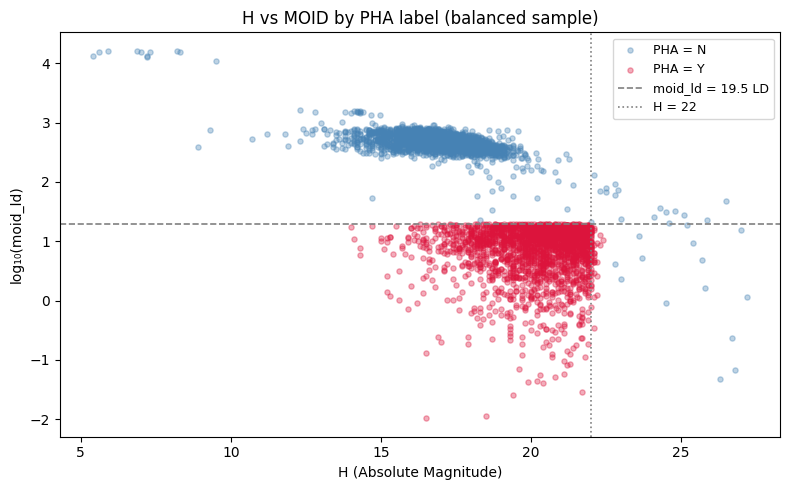

In [ ]:
tmp = df_sample[['pha', 'H', 'moid_ld']].dropna()
tmp = tmp[tmp['moid_ld'] > 0].copy()
tmp['log_moid'] = np.log10(tmp['moid_ld'])

colors = {'Y': 'crimson', 'N': 'steelblue'}
plt.figure(figsize=(8, 5))
for label, grp in tmp.groupby('pha'):
    plt.scatter(grp['H'], grp['log_moid'],
                c=colors[label], alpha=0.35, s=14, label=f'PHA = {label}')

plt.axhline(np.log10(19.5), color='gray', linestyle='--', linewidth=1.2,
            label='moid_ld = 19.5 LD')
plt.axvline(22, color='gray', linestyle=':', linewidth=1.2,
            label='H = 22')
plt.xlabel('H (Absolute Magnitude)')
plt.ylabel('log₁₀(moid_ld)')
plt.title('H vs MOID by PHA label (balanced sample)')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()


**Findings:** PHA = Y objects (red) concentrate tightly in the lower-left quadrant — below moid_ld = 19.5 LD and left of H = 22 — exactly as the PHA definition predicts. PHA = N objects (blue) dominate the rest of the space, most with very high MOID. Two edge cases are visible: small objects with low MOID but H > 22 (not large enough), and large objects with low H but high MOID (orbit too far). This confirms that **both criteria must be met simultaneously**.

# Final Plots (Effective Data Visualization)

Below we present **3 enhanced multivariate visualizations** from the previous section, refined for a general audience. Each plot is designed to be self-explanatory for someone with no astronomy background.

### Final Plot 1 — Enhanced: Two-Criterion PHA Region

Enhanced version of the H × MOID scatter above, designed for an audience unfamiliar with orbital mechanics. The PHA selection zone is explicitly shaded, thresholds are annotated, and the axes are labeled in plain language.

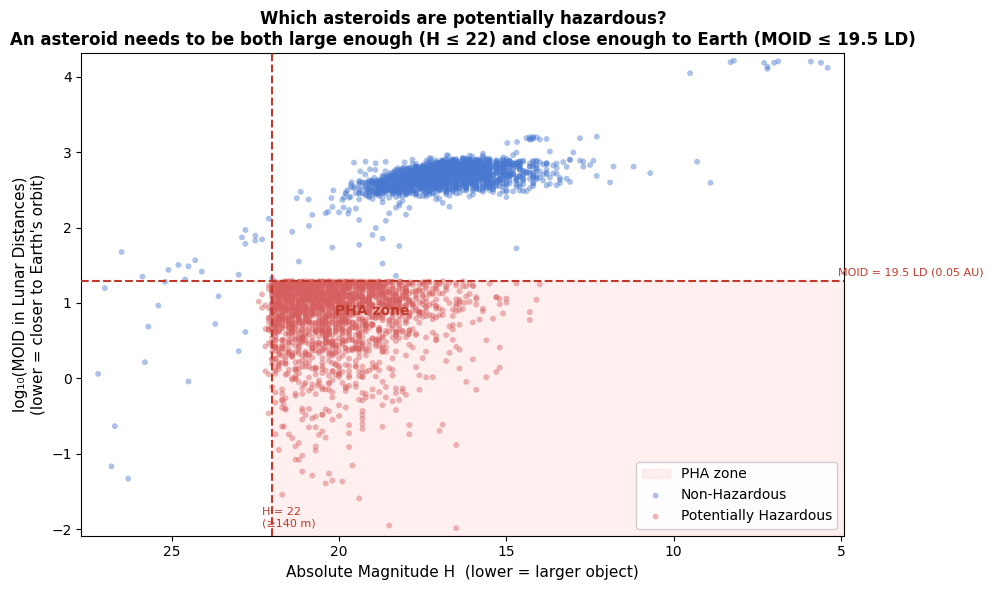

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

tmp = df_sample[['pha', 'H', 'moid_ld']].dropna()
tmp = tmp[tmp['moid_ld'] > 0].copy()
tmp['log_moid'] = np.log10(tmp['moid_ld'])
ymin = tmp['log_moid'].min() - 0.1
ymax = tmp['log_moid'].max() + 0.1
xmin = tmp['H'].min() - 0.5
xmax = tmp['H'].max() + 0.5

# Shade the PHA zone
ax.fill_betweenx([ymin, np.log10(19.5)], xmin, 22,
                 color='#ffe0e0', alpha=0.5, zorder=0, label='PHA zone')

# Scatter
palette = {'N': '#4878CF', 'Y': '#D65F5F'}
for label, grp in tmp.groupby('pha'):
    ax.scatter(grp['H'], grp['log_moid'],
               c=palette[label], alpha=0.45, s=18, edgecolors='none',
               label='Potentially Hazardous' if label == 'Y' else 'Non-Hazardous')

# Threshold lines
ax.axhline(np.log10(19.5), color='#c0392b', linestyle='--', linewidth=1.5, zorder=3)
ax.axvline(22, color='#c0392b', linestyle='--', linewidth=1.5, zorder=3)

# Annotations
ax.text(22.3, ymin + 0.1, 'H = 22\n(≥140 m)',
        color='#c0392b', fontsize=8, va='bottom')
ax.text(xmin + 0.2, np.log10(19.5) + 0.07,
        'MOID = 19.5 LD (0.05 AU)', color='#c0392b', fontsize=8)
ax.text(19, np.log10(19.5) - 0.45, 'PHA zone',
        color='#c0392b', fontsize=10, fontweight='bold', ha='center')

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_xlabel('Absolute Magnitude H  (lower = larger object)', fontsize=11)
ax.set_ylabel('log₁₀(MOID in Lunar Distances)\n(lower = closer to Earth\'s orbit)', fontsize=11)
ax.set_title(
    'Which asteroids are potentially hazardous?\n'
    'An asteroid needs to be both large enough (H ≤ 22) and close enough to Earth (MOID ≤ 19.5 LD)',
    fontsize=12, fontweight='bold'
)
ax.invert_xaxis()
ax.legend(fontsize=10, framealpha=0.9)
plt.tight_layout()
plt.show()


**Description:** Asteroids plotted by size (H, x-axis inverted) against orbit proximity to Earth (log₁₀ MOID, y-axis). The shaded pink zone marks where **both** PHA criteria are met. PHAs (red) cluster almost entirely inside; non-PHAs (blue) scatter outside.

**Key finding:** Neither criterion alone defines a PHA. The joint threshold forms a clean 2D boundary: an object must be large enough to survive atmospheric entry AND its orbit must bring it close to Earth.

### Final Plot 2 — Asteroid Orbit Shapes by PHA Class

Enhanced version of Multivariate 3, showing the **actual orbital ellipses** instead of abstract scatter points. Each curve is one asteroid's orbit drawn as an ellipse around the Sun. This visualization makes the physical difference between hazardous and non-hazardous orbits immediately intuitive — even for someone with no astronomy background.

**How to read this plot:** The gold dot is the Sun. The green dashed circle is Earth's orbit (~1 AU radius). Each colored curve is one asteroid's orbit. Orange curves = potentially hazardous asteroids; blue curves = non-hazardous. The more an orange orbit overlaps with the green circle, the closer that asteroid passes to Earth.

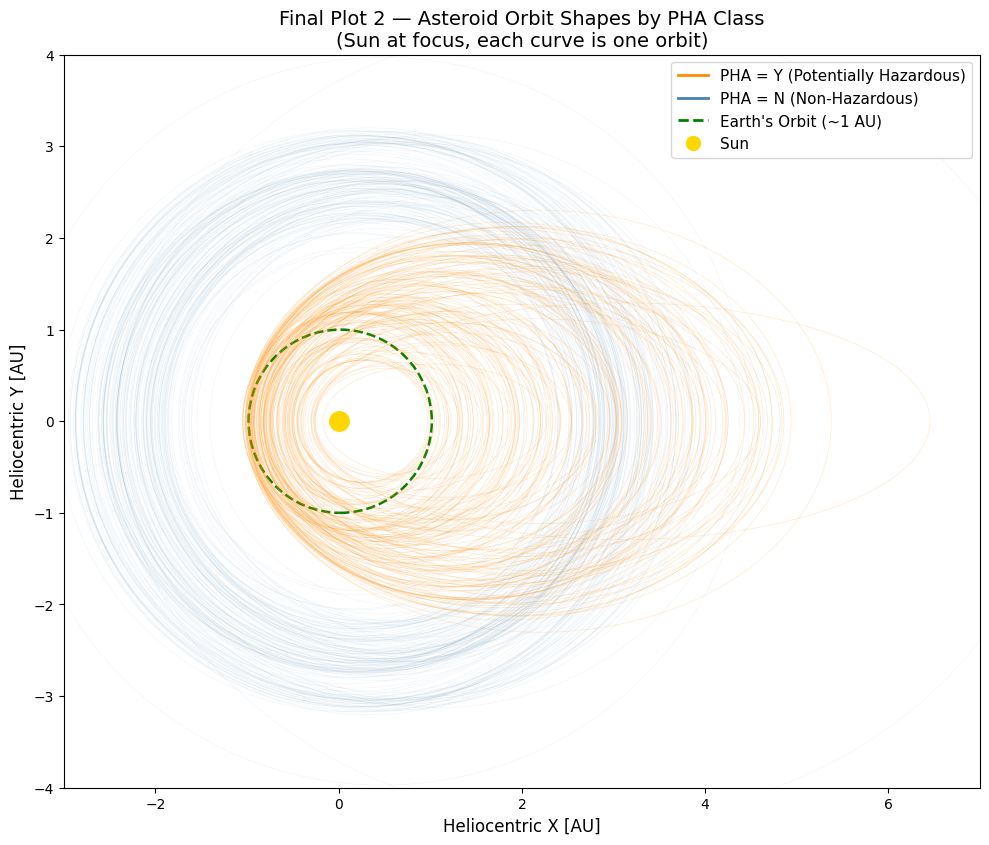

In [52]:
from matplotlib.patches import Ellipse as MplEllipse
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(10, 10))

ax.plot(0, 0, 'o', color='gold', markersize=14, zorder=5)

earth_e = 0.017
earth = MplEllipse(xy=(1 * earth_e, 0), width=2 * 1,
                   height=2 * 1 * np.sqrt(1 - earth_e**2),
                   edgecolor='green', facecolor='none', linestyle='--',
                   linewidth=1.8)
ax.add_patch(earth)

colors = {'N': 'steelblue', 'Y': 'darkorange'}
alphas = {'N': 0.07, 'Y': 0.18}

for label in ['N', 'Y']:
    sub = df_sample[df_sample['pha'] == label].dropna(subset=['a', 'e'])
    sub = sub[(sub['a'] < 6) & (sub['e'] < 1) & (sub['e'] >= 0)]
    sub = sub.sample(n=min(150, len(sub)), random_state=42)
    for _, row in sub.iterrows():
        a_val, e_val = row['a'], row['e']
        b_val = a_val * np.sqrt(1 - e_val**2)
        c_val = a_val * e_val
        orb = MplEllipse(xy=(c_val, 0), width=2 * a_val, height=2 * b_val,
                         edgecolor=colors[label], facecolor='none',
                         linewidth=0.5, alpha=alphas[label])
        ax.add_patch(orb)

ax.set_xlim(-3, 7)
ax.set_ylim(-4, 4)
ax.set_aspect('equal')
ax.set_title('Final Plot 2 — Asteroid Orbit Shapes by PHA Class\n'
             '(Sun at focus, each curve is one orbit)', fontsize=14)
ax.set_xlabel('Heliocentric X [AU]', fontsize=12)
ax.set_ylabel('Heliocentric Y [AU]', fontsize=12)

handles = [Line2D([0], [0], color='darkorange', lw=2,
                   label='PHA = Y (Potentially Hazardous)'),
           Line2D([0], [0], color='steelblue', lw=2,
                   label='PHA = N (Non-Hazardous)'),
           Line2D([0], [0], color='green', lw=2, ls='--',
                   label="Earth's Orbit (~1 AU)"),
           Line2D([0], [0], marker='o', color='gold', lw=0, ms=10,
                   label='Sun')]
ax.legend(handles=handles, loc='upper right', fontsize=11)
plt.tight_layout()
plt.show()

**Description:** Each curve is one asteroid’s orbit around the Sun (gold dot). Orange = potentially hazardous; blue = non-hazardous. Green dashed circle = Earth’s orbit. 150 orbits per class sampled for readability.

**Key finding:** PHA orbits are visibly more elongated and cross Earth’s orbit, while non-PHA orbits stay farther out in the main belt. This directly shows why eccentricity and semi-major axis are the defining features of hazardous asteroids.

### Final Plot 3 — Orbit Shape vs Size with Earth-Crossing Risk Zone

Enhanced version of Multivariate 3 (a vs e scatter), designed for a lay audience. The key improvement is the **red-shaded risk zone** that marks every orbit physically capable of crossing Earth's distance from the Sun. An asteroid's orbit crosses Earth's if its closest point to the Sun (perihelion = a(1−e)) is less than 1 AU while its farthest point (aphelion = a(1+e)) is greater than 1 AU. Simplifying: **e > |1 − a| / a**.

**How to read this plot:** Each dot is one asteroid. The x-axis is the average orbit radius in AU (1 AU = Earth–Sun distance). The y-axis is eccentricity (0 = circular, 1 = very elongated). The red area marks orbits that cross Earth's distance. The black dot marks Earth itself.

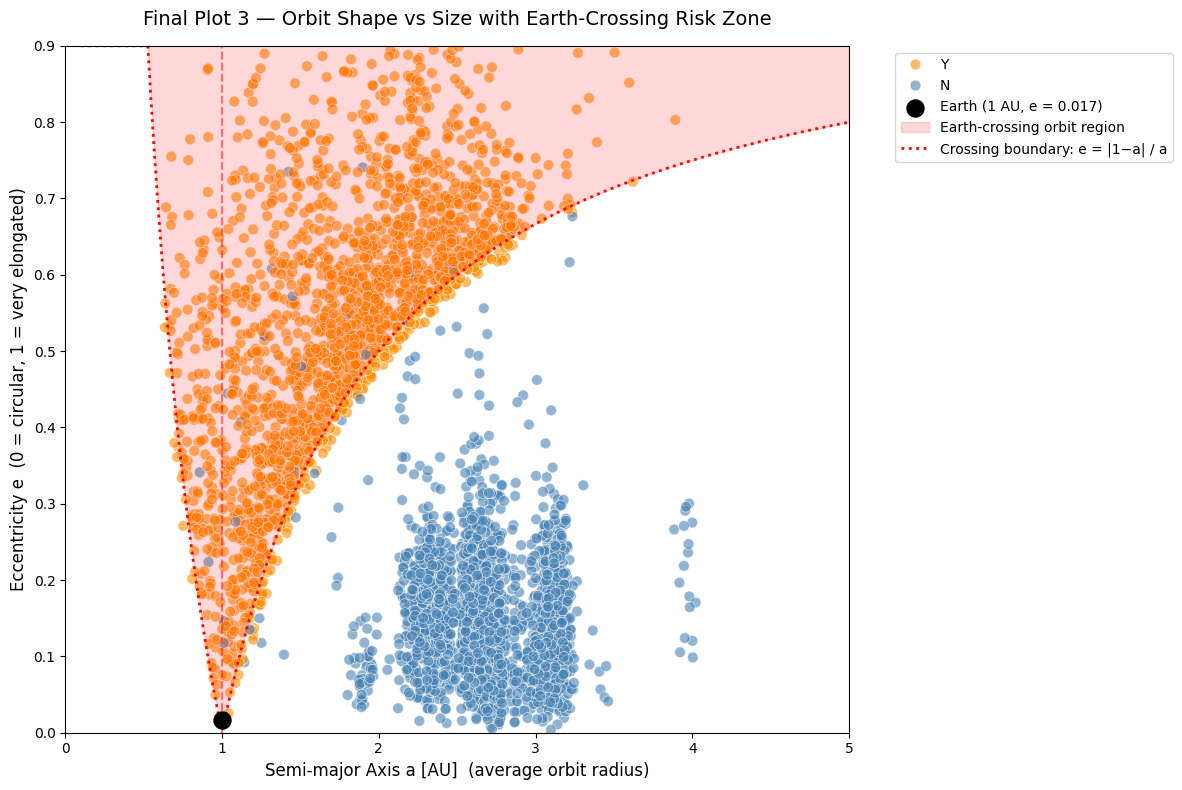

In [53]:
tmp_final = df_sample[['a', 'e', 'pha']].dropna()
tmp_final = tmp_final[(tmp_final['a'] < 5) & (tmp_final['e'] < 0.9)]

plt.figure(figsize=(12, 8))
sns.scatterplot(data=tmp_final, x='a', y='e', hue='pha',
                palette={'Y': 'darkorange', 'N': 'steelblue'},
                s=60, alpha=0.6)

plt.scatter(1, 0.017, color='black', s=150, zorder=5, edgecolors='black',
            linewidth=1, label='Earth (1 AU, e = 0.017)')

a_range = np.linspace(0.1, 5, 1000)
e_cross = np.abs(1 - a_range) / a_range
e_cross = np.clip(e_cross, 0, 0.9)
plt.fill_between(a_range, e_cross, 0.9, alpha=0.15, color='red',
                 label='Earth-crossing orbit region')
plt.plot(a_range, e_cross, 'r:', linewidth=2,
         label='Crossing boundary: e = |1−a| / a')
plt.axvline(x=1, color='red', ls='--', alpha=0.5)

plt.title('Final Plot 3 — Orbit Shape vs Size with Earth-Crossing Risk Zone',
          fontsize=14, pad=15)
plt.xlabel('Semi-major Axis a [AU]  (average orbit radius)', fontsize=12)
plt.ylabel('Eccentricity e  (0 = circular, 1 = very elongated)', fontsize=12)
plt.xlim(0, 5)
plt.ylim(0, 0.9)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

**Description:** Each dot is an asteroid. X-axis = average orbit radius (AU). Y-axis = eccentricity. The red zone marks orbits that physically cross Earth’s distance (e > |1−a| / a). Black dot = Earth.

**Key finding:** Nearly all PHAs sit inside the red risk zone; most non-PHAs sit below with circular, distant orbits. The boundary curve cleanly separates the two populations, confirming that **orbital geometry alone** identifies potentially hazardous asteroids.

# Digest

Below we summarize the main findings of the project and provide a critical reflection on the work, the effort invested, what went well, and what we would approach differently.

#### Main Findings

The first challenge of the project was to select an appropriate dataset. Although there are endless alternatives in big data, we struggled to find a reliable one that contained enough columns and would allow us to do a thorough analysis. The Asteroids dataset turned out to be an excellent option because most of its parameters are mathematically defined — orbital mechanics provides precise, objective measurements rather than subjective labels.

After exploring the 38 features of the cleaned dataset (938,603 instances), our key findings are:

1. **PHAs are extremely rare** — only 0.22 % of the catalogue. This severe class imbalance shaped every analysis decision, from balanced sampling to metric selection.
2. **Orbital geometry defines hazardousness.** The two formal PHA criteria (absolute magnitude H ≤ 22 and MOID ≤ 19.5 lunar distances) create a clean two-dimensional boundary. Eccentricity and semi-major axis emerged as the strongest individual discriminators.
3. **Surface properties are uninformative.** Diameter and albedo do not meaningfully separate PHA from non-PHA asteroids — a non-obvious finding that underscores the dominance of orbital parameters.
4. **Strong multicollinearity** among orbital variables (a, ad, per_y, q) is expected from Kepler's laws and must be handled during feature selection for the machine learning stage.

#### Critical Reflection

Several assumptions and limitations deserve acknowledgement. The balanced sampling approach (equal Y and N counts) made exploratory plots easier to read, but discards the vast majority of N-class instances — any population-level statistic must still be drawn from the full `df_clean`. Some columns (diameter, albedo) have ~86 % missing values, so conclusions about physical properties are limited to the well-observed subset. At this checkpoint stage, the project covers exploratory analysis only; the machine learning pipeline (classification, hyperparameter tuning, validation) is deferred to the final submission.

#### Effort and Process

The team divided the work into parallel tracks covering data loading, cleaning, balanced sampling, univariate analyses (20 variables), multivariate visualizations (7 analyses including the H × MOID scatter and Spearman correlation), and the three final enhanced plots (orbital ellipses, risk-zone scatter, PHA region). The Spearman correlation analysis and the four additional univariate variables (ma, moid, sigma_e, rms) were added during the final integration pass. We used Python (pandas, numpy, matplotlib, seaborn, scipy) exclusively, running on Google Colab and local Jupyter environments.

#### What Went Well

The hypothesis-driven approach for multivariate analysis kept the narrative focused and made each plot's purpose clear. The orbital-ellipse visualization (Final Plot 2) turned out to be the most intuitive representation — even someone with no astronomy background can immediately see why certain orbits are dangerous. Defining variables of interest early helped us avoid scattershot exploration. The Spearman correlation heatmap provided a concise summary of multicollinearity that will directly inform feature engineering in the ML phase.

#### What We Would Do Differently

In hindsight, we should have started with the correlation analysis before plotting individual multivariate figures — it would have guided our variable selection from the start. We also underestimated the impact of missing data in diameter/albedo; exploring imputation strategies earlier could have enabled richer analyses of physical properties. Finally, the univariate discussions for the initial variables (pha, neo, a, e, i, albedo, diameter) were initially left as brief comments without formal statistics — integrating the full discussion template from the beginning would have saved revision time later.